# 05 · Mô hình định giá

- **Người phụ trách:** Đỗ Khánh Duy
- **Đầu vào:** `data/processed/cars_cleaned.csv` (notebook 02), `data/processed/text_flags.csv` (notebook 04)
- **Đầu ra:** `models/car_pricing_model.pkl`, dùng ở notebook 06
- **Liên quan proposal:** mục tiêu *Thẩm định giá độc lập*; tiêu chí R² > 0,85 trên tập kiểm tra

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

CLEAN_PATH = ROOT / "data" / "processed" / "cars_cleaned.csv"
TEXT_FLAGS_PATH = ROOT / "data" / "processed" / "text_flags.csv"
MODEL_PATH = ROOT / "models" / "car_pricing_model.pkl"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RANDOM_STATE = 42
TARGET_COLUMN = "price_million"
R2_TARGET = 0.85

## 1. Bài toán hồi quy

Mỗi dòng dữ liệu tương ứng với một tin rao bán xe. Mô hình hồi quy dự đoán **giá niêm yết** từ các đặc trưng như tuổi xe, số kilomet đã đi, hãng và dòng xe. Biến mục tiêu là `price_million`, có đơn vị **triệu VNĐ**, được chuẩn hóa ở notebook 02 theo `price_million = price / 1_000_000`. Ví dụ, giá trị 450 tương ứng với 450 triệu đồng.

### Chỉ số đánh giá

| Chỉ số | Cách tính | Ý nghĩa thực tế | Tiêu chí |
|---|---|---|---|
| **R²** | $1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$ | Đo mức biến thiên giá được mô hình giải thích. R² = 0,85 tương ứng giải thích 85% biến thiên giá trên tập đánh giá. R² = 1 là dự đoán hoàn hảo; R² = 0 tương đương dự đoán giá trung bình của tập đánh giá; R² âm là kém hơn mốc này. | **R² > 0,85 trên tập test**; càng cao càng tốt. |
| **MAE** | $\frac{1}{n}\sum_i \lvert y_i - \hat{y}_i \rvert$ | Sai lệch tuyệt đối trung bình, tính bằng triệu VNĐ. MAE = 30 nghĩa là giá dự đoán lệch trung bình 30 triệu đồng mỗi xe. | Càng thấp càng tốt. |
| **RMSE** | $\sqrt{\frac{1}{n}\sum_i (y_i - \hat{y}_i)^2}$ | Căn sai số bình phương trung bình, cũng tính bằng triệu VNĐ. Bình phương sai số làm các lần định giá sai lớn có trọng số cao hơn; RMSE lớn hơn nhiều so với MAE gợi ý có những sai lệch lớn cần phân tích. | Càng thấp càng tốt. |

Trong các công thức, $y_i$ là giá niêm yết thực tế, $\hat{y}_i$ là giá dự đoán, $\bar{y}$ là giá trung bình của tập đánh giá và $n$ là số tin được đánh giá. R² không phải tỷ lệ xe được dự đoán đúng hoặc phần trăm sai số giá.

Ngưỡng 0,85 là mục tiêu cần kiểm chứng sau huấn luyện. Chỉ kết luận đạt khi R² trên tập test **lớn hơn** ngưỡng này; báo cáo đồng thời MAE và RMSE để biết mức sai lệch bằng tiền. Việc chọn mô hình và tinh chỉnh sử dụng tập train cùng cross-validation, dành tập test cho đánh giá cuối cùng.

Không sử dụng `price`, `price_string` hoặc `price_million` làm đặc trưng đầu vào vì chúng trực tiếp chứa giá cần dự đoán. Phần 2 sẽ xác định tập đặc trưng; phần 3 và 4 sẽ chia dữ liệu và huấn luyện.

Dữ liệu đầu vào đã được notebook 02 điền ODO bằng trung vị và lọc ngoại lai IQR trước khi chia tập. Kết quả sau này phản ánh tập dữ liệu đã xử lý này; các bước tiền xử lý mới ở notebook 05 cần được fit trên tập train trong Pipeline.

Tham khảo cách tính: [scikit-learn: Regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics).

In [2]:
df = pd.read_csv(CLEAN_PATH, low_memory=False)

if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Thiếu biến mục tiêu {TARGET_COLUMN} trong {CLEAN_PATH.name}.")

y = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
invalid_price_mask = ~np.isfinite(y) | y.le(0)

if invalid_price_mask.any():
    raise ValueError(
        f"Có {invalid_price_mask.sum():,} giá bị thiếu, không hữu hạn hoặc không dương. "
        "Cần kiểm tra dữ liệu trước khi huấn luyện."
    )
if y.size < 2 or y.nunique() < 2:
    raise ValueError("Cần ít nhất hai tin với giá khác nhau để đánh giá R².")

df[TARGET_COLUMN] = y

target_summary = pd.Series(
    {
        "Số tin": y.size,
        "Giá thấp nhất (triệu VNĐ)": y.min(),
        "Giá trung vị (triệu VNĐ)": y.median(),
        "Giá trung bình (triệu VNĐ)": y.mean(),
        "Giá cao nhất (triệu VNĐ)": y.max(),
    },
    name=TARGET_COLUMN,
).to_frame()

target_summary

,price_million
Số tin,13520.000000
Giá thấp nhất (triệu VNĐ),20.000000
Giá trung vị (triệu VNĐ),425.000000
Giá trung bình (triệu VNĐ),456.457285
Giá cao nhất (triệu VNĐ),1180.000000


### Hàm đánh giá dùng ở bước huấn luyện

`evaluate_regression(y_true, y_pred)` nhận giá thực tế và giá dự đoán theo cùng thứ tự tin, cùng đơn vị triệu VNĐ. Hàm trả về R², MAE, RMSE và kết quả kiểm tra ngưỡng R². Ví dụ ở phần 4: `test_metrics = evaluate_regression(y_test, model.predict(X_test))`.

Phần 1 chuẩn bị biến mục tiêu và cách đánh giá; chưa có kết quả của mô hình được huấn luyện.

In [3]:
from car_pricing.evaluation import evaluate_regression

## 2. Chọn đặc trưng và mã hóa

Đặc trưng được chọn theo danh sách cố định trong `car_pricing/features.py`. Mỗi tin có **21 đặc trưng** thuộc ba nhóm:

| Nhóm | Đặc trưng | Cách xử lý |
|---|---|---|
| **Số** | `car_age`, `mileage_v2` | Điền giá trị thiếu bằng trung vị của train, sau đó chuẩn hóa bằng StandardScaler. |
| **Danh mục** | `carbrand_name`, `carmodel_name`, `gearbox`, `fuel`, `cartype`, `carcolor`, `carorigin`, `carseats`, `region_name` | Gán nhãn `Không rõ` cho giá trị thiếu và one-hot encoding; gom nhóm hiếm riêng cho dòng xe. |
| **Cờ văn bản** | `co_mo_ta` và 9 cờ `vb_*` từ notebook 04 | Giữ nguyên giá trị 0/1, không chuẩn hóa. |

Tuổi xe biểu diễn thông tin năm sản xuất nên không dùng thêm `mfdate`. Các cột giá, mã tin, mã danh mục trùng thông tin nhãn, tiêu đề, mô tả thô và thời gian thu thập nằm ngoài tập đầu vào.

Ghép `text_flags.csv` với dữ liệu sạch theo `list_id`, kiểm tra khóa duy nhất, không thiếu và khớp giữa hai file. Phép ghép giữ thứ tự tin để `X` và `y` tương ứng từng dòng; cờ thiếu hoặc khác 0/1 sẽ báo lỗi để kiểm tra notebook 04.

`co_mo_ta` đánh dấu có mô tả được thu thập. Notebook 04 tìm từ khóa trên cả tiêu đề và mô tả, vì vậy `co_mo_ta = 0` vẫn có thể đi kèm cờ `vb_* = 1`. Các cờ phản ánh nội dung người bán viết.

In [4]:
from IPython.display import display

from car_pricing.features import (
    CATEGORICAL_FEATURES,
    FEATURE_COLUMNS,
    NUMERIC_FEATURES,
    TEXT_FEATURES,
    build_feature_dataset,
)
from car_pricing.preprocessing import build_preprocessor

text_flags = pd.read_csv(TEXT_FLAGS_PATH, low_memory=False)
modeling_data = build_feature_dataset(df, text_flags)
X = modeling_data.loc[:, list(FEATURE_COLUMNS)].copy()
y = modeling_data[TARGET_COLUMN].copy()

feature_groups = {
    "Số": NUMERIC_FEATURES,
    "Danh mục": CATEGORICAL_FEATURES,
    "Cờ văn bản": TEXT_FEATURES,
}
feature_summary = pd.DataFrame(
    [
        {
            "Nhóm": group,
            "Đặc trưng": column,
            "Giá trị thiếu": int(X[column].isna().sum()),
            "Tỷ lệ thiếu (%)": round(X[column].isna().mean() * 100, 2),
            "Số giá trị": X[column].nunique(),
        }
        for group, columns in feature_groups.items()
        for column in columns
    ]
)

print(f"Đã ghép {len(modeling_data):,} tin; X có {X.shape[1]} đặc trưng; y là {y.name}.")
display(feature_summary)

Đã ghép 13,520 tin; X có 21 đặc trưng; y là price_million.


,Nhóm,Đặc trưng,Giá trị thiếu,Tỷ lệ thiếu (%),Số giá trị
0,Số,car_age,0,0.00,43
1,Số,mileage_v2,0,0.00,1862
2,Danh mục,carbrand_name,0,0.00,56
3,Danh mục,carmodel_name,0,0.00,372
4,Danh mục,gearbox,0,0.00,3
5,Danh mục,fuel,0,0.00,4
6,Danh mục,cartype,5096,37.69,9
7,Danh mục,carcolor,521,3.85,12
8,Danh mục,carorigin,6381,47.20,10
9,Danh mục,carseats,3489,25.81,10


### Gom nhóm dòng xe hiếm

CSV hiện có **372** giá trị `carmodel_name`; **211** dòng xe có dưới 10 tin trên toàn bộ dữ liệu. Bảng dưới kiểm tra lại số liệu mỗi lần chạy, thay cho con số 422 trong hướng dẫn ban đầu.

Chọn `OneHotEncoder(min_frequency=10, handle_unknown="infrequent_if_exist")`: các dòng xe có dưới 10 tin trong **tập train** dùng chung một cột nhóm hiếm. Dòng xe mới ở test được đưa vào nhóm hiếm nếu nhóm này tồn tại; nếu train không có nhóm hiếm, encoder trả về các cột dòng xe bằng 0. Cách này giảm số cột và không dùng giá mục tiêu để mã hóa. Target encoding cần cơ chế cross-fitting để kiểm soát rò rỉ mục tiêu.

Thống kê trên toàn bộ dữ liệu ở đây phục vụ mô tả. Việc xác định nhóm hiếm thực tế chỉ diễn ra khi fit Pipeline trên train.

Tham khảo: [scikit-learn: OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

In [5]:
MIN_MODEL_FREQUENCY = 10

model_counts = X["carmodel_name"].value_counts()
rare_models = model_counts[model_counts < MIN_MODEL_FREQUENCY]
model_summary = pd.DataFrame(
    [
        {
            "Số dòng xe": model_counts.size,
            "Dòng xe dưới ngưỡng": rare_models.size,
            "Số tin thuộc dòng hiếm": int(rare_models.sum()),
            "Ngưỡng số tin": MIN_MODEL_FREQUENCY,
        }
    ]
)

model_summary

,Số dòng xe,Dòng xe dưới ngưỡng,Số tin thuộc dòng hiếm,Ngưỡng số tin
0,372,211,630,10


### Chuẩn bị bộ tiền xử lý

`car_pricing/preprocessing.py` tạo `ColumnTransformer` với Pipeline riêng cho số, danh mục và dòng xe; cờ văn bản được chuyển tiếp trực tiếp. Encoder cho các danh mục còn lại dùng `handle_unknown="ignore"` để nhận giá trị mới khi dự đoán.

Ở phần này chỉ khởi tạo `preprocessor`, **chưa gọi fit hoặc fit_transform**. Phần 3 chia train/test và tạo Pipeline gồm tiền xử lý cùng mô hình; phần 4 fit Pipeline trên `X_train, y_train`. Trung vị, tham số chuẩn hóa, các nhóm hiếm và cột one-hot đều được học từ train; test chỉ dùng transform hoặc predict.

Các bước mới này kiểm soát việc học từ test tại notebook 05. Việc điền ODO và lọc IQR trước đó trong notebook 02 đã được nêu ở phần 1.

In [6]:
preprocessor = build_preprocessor(min_model_frequency=MIN_MODEL_FREQUENCY)

encoding_summary = pd.DataFrame(
    [
        {"Nhóm": "Số", "Số cột đầu vào": len(NUMERIC_FEATURES), "Xử lý": "Median imputation + StandardScaler"},
        {"Nhóm": "Danh mục", "Số cột đầu vào": len(CATEGORICAL_FEATURES) - 1, "Xử lý": "Nhãn thiếu + OneHotEncoder"},
        {"Nhóm": "Dòng xe", "Số cột đầu vào": 1, "Xử lý": f"Nhãn thiếu + OneHotEncoder, min_frequency={MIN_MODEL_FREQUENCY}"},
        {"Nhóm": "Cờ văn bản", "Số cột đầu vào": len(TEXT_FEATURES), "Xử lý": "Giữ nguyên 0/1"},
    ]
)

encoding_summary

,Nhóm,Số cột đầu vào,Xử lý
0,Số,2,Median imputation + StandardScaler
1,Danh mục,8,Nhãn thiếu + OneHotEncoder
2,Dòng xe,1,"Nhãn thiếu + OneHotEncoder, min_frequency=10"
3,Cờ văn bản,10,Giữ nguyên 0/1


## 3. Chia tập train/test

Dùng `train_test_split` để chia **80% train / 20% test**, với `random_state=42` và xáo trộn trước khi chia. Seed cố định giúp tái lập cách chia khi dữ liệu và thứ tự tin đầu vào giữ nguyên.

Chia đồng thời `X`, `y` và `list_id` để đặc trưng, giá và mã tin vẫn tương ứng từng dòng. `list_id` chỉ dùng kiểm tra hai tập không trùng tin, không đưa vào đặc trưng mô hình. Giữ các đặc trưng ở dạng chưa mã hóa sau khi chia.

Tập train dùng để học tiền xử lý, huấn luyện và cross-validation khi chọn mô hình hoặc tinh chỉnh. Tập test được giữ lại để đánh giá cuối cùng bằng R², MAE và RMSE; không dùng test để fit hoặc điều chỉnh mô hình.

Bảng dưới ghi số tin, tỷ lệ, số đặc trưng và giá trung vị của mỗi tập.

Tham khảo: [scikit-learn: train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [7]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2

if not X.index.equals(y.index) or not X.index.equals(modeling_data.index):
    raise ValueError("Đặc trưng, giá và mã tin phải có cùng thứ tự dòng trước khi chia tập.")

X_train, X_test, y_train, y_test, train_listing_ids, test_listing_ids = train_test_split(
    X,
    y,
    modeling_data["list_id"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

if not X_train.index.equals(y_train.index) or not X_test.index.equals(y_test.index):
    raise ValueError("Đặc trưng và giá không khớp dòng sau khi chia tập.")
if train_listing_ids.isin(test_listing_ids).any():
    raise ValueError("Có tin xuất hiện đồng thời trong train và test.")

split_summary = pd.DataFrame(
    [
        {
            "Tập": name,
            "Số tin": len(features),
            "Tỷ lệ (%)": round(len(features) / len(X) * 100, 2),
            "Số đặc trưng": features.shape[1],
            "Giá trung vị (triệu VNĐ)": target.median(),
        }
        for name, features, target in (
            ("Train", X_train, y_train),
            ("Test", X_test, y_test),
        )
    ]
)

split_summary

,Tập,Số tin,Tỷ lệ (%),Số đặc trưng,Giá trung vị (triệu VNĐ)
0,Train,10816,80.0,21,425.0
1,Test,2704,20.0,21,426.0


### Đặt tiền xử lý trong Pipeline

`build_model_pipeline` trong `car_pricing/preprocessing.py` tạo một Pipeline gồm bộ tiền xử lý và mô hình. Mỗi lần gọi tạo preprocessor mới và clone mô hình, để các lần huấn luyện có trạng thái học độc lập.

Pipeline chứa toàn bộ bước điền giá trị thiếu, chuẩn hóa số, gom dòng xe hiếm và one-hot encoding đã định nghĩa ở phần 2. Khi phần 4 fit Pipeline trên `X_train, y_train`, các bước này chỉ học từ train. Lệnh `baseline_pipeline.predict(X_test)` sử dụng lại các tham số đã học rồi dự đoán trên test.

Cell dưới chuẩn bị `baseline_pipeline` với Linear Regression, **chưa gọi fit**. Các mô hình khác ở phần 4 dùng cùng hàm tạo Pipeline; cross-validation cũng phải nhận Pipeline hoàn chỉnh cùng đặc trưng chưa mã hóa.

Phạm vi kiểm soát rò rỉ ở đây là các bước mới trong notebook 05. Giới hạn của dữ liệu đã xử lý ở notebook 02 được nêu trong phần 1.

Tham khảo: [scikit-learn: tránh rò rỉ dữ liệu với Pipeline](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

In [8]:
from sklearn.linear_model import LinearRegression

from car_pricing.preprocessing import build_model_pipeline

baseline_pipeline = build_model_pipeline(
    LinearRegression(),
    min_model_frequency=MIN_MODEL_FREQUENCY,
)

pipeline_summary = pd.DataFrame(
    [
        {"Bước": "preprocessor", "Thành phần": "ColumnTransformer", "Trạng thái": "Chưa fit"},
        {"Bước": "model", "Thành phần": "LinearRegression", "Trạng thái": "Chưa fit"},
    ]
)

pipeline_summary

,Bước,Thành phần,Trạng thái
0,preprocessor,ColumnTransformer,Chưa fit
1,model,LinearRegression,Chưa fit


## 4. Huấn luyện và so sánh mô hình

Huấn luyện bốn mô hình trên cùng `X_train, y_train` đã chia ở phần 3. Mỗi mô hình có Pipeline riêng chứa toàn bộ tiền xử lý; tập test chỉ đi qua predict để tính chỉ số đánh giá.

| Mô hình | Vai trò | Cấu hình khởi đầu |
|---|---|---|
| **Linear Regression** | Baseline tuyến tính để đối chiếu các mô hình cây. | Tham số mặc định của scikit-learn. |
| **Decision Tree** | Học quan hệ phi tuyến bằng một cây quyết định. | `min_samples_leaf=2`, `random_state=42`. |
| **Random Forest** | Tổng hợp nhiều cây học trên các mẫu bootstrap. | `n_estimators=300`, `min_samples_leaf=2`, `random_state=42`. |
| **XGBoost** | Boosting cây theo sai số của các bước trước. | `n_estimators=400`, `max_depth=6`, `learning_rate=0.05`, `subsample=0.9`, `colsample_bytree=0.9`, `reg_lambda=1.0`, `random_state=42`. |

Cấu hình được cố định trước khi xem kết quả test. Random Forest và XGBoost dùng 4 luồng CPU; XGBoost dùng `tree_method="hist"` và `objective="reg:squarederror"`.

Pipeline XGBoost xuất ma trận **dense** để giữ các giá trị 0 của one-hot, cờ văn bản và số đã chuẩn hóa. Các Pipeline còn lại giữ đầu ra sparse. Bộ cây của XGBoost coi phần tử không được lưu trong sparse là giá trị thiếu; định dạng dense giúp giá trị 0 được biểu diễn rõ ràng. Tham khảo: [XGBoost: sparse và dense](https://xgboost.readthedocs.io/en/stable/faq.html#why-do-i-see-different-results-with-sparse-and-dense-data).

`car_pricing/training.py` quản lý cấu hình và vòng lặp huấn luyện; `car_pricing/evaluation.py` tính các chỉ số đã định nghĩa ở phần 1. Kết quả gồm `trained_models` (Pipeline đã fit), `model_predictions` (giá dự đoán theo index từng tập) và `comparison_table` (chỉ số chưa làm tròn).

In [9]:
from car_pricing.training import build_model_pipelines, train_and_compare_models

N_JOBS = 4

model_pipelines = build_model_pipelines(
    random_state=RANDOM_STATE,
    min_model_frequency=MIN_MODEL_FREQUENCY,
    n_jobs=N_JOBS,
)
trained_models, model_predictions, comparison_table = train_and_compare_models(
    model_pipelines,
    X_train,
    y_train,
    X_test,
    y_test,
    r2_target=R2_TARGET,
)
baseline_pipeline = trained_models["Linear Regression"]

print(f"Đã huấn luyện {len(trained_models)} mô hình trên {len(X_train):,} tin train.")

Đã huấn luyện 4 mô hình trên 10,816 tin train.


### Bảng đánh giá trên train và test

Báo cáo **R², MAE và RMSE trên cả hai tập**. MAE và RMSE có đơn vị **triệu VNĐ**; R² càng cao và hai sai số càng thấp thì kết quả càng tốt. Cột `R2_gap` là R² train trừ R² test: chênh lệch lớn gợi ý mô hình học tốt trên train nhưng khái quát kém hơn trên test.

`Meets_R2_target` kiểm tra điều kiện **R² test > 0,85** trên điểm chưa làm tròn. Bảng hiển thị làm tròn R² đến 4 chữ số và MAE/RMSE đến 2 chữ số; `comparison_table` giữ nguyên độ chính xác cho các bước sau.

Đây là kết quả của cấu hình khởi đầu trên dữ liệu đã xử lý ở notebook 02. Phần 5 cần dùng cross-validation trên train để tinh chỉnh và chọn mô hình; bảng test ở đây phục vụ báo cáo so sánh.

In [10]:
comparison_display = comparison_table.round(
    {
        "R2_train": 4,
        "MAE_train": 2,
        "RMSE_train": 2,
        "R2_test": 4,
        "MAE_test": 2,
        "RMSE_test": 2,
        "R2_gap": 4,
    }
)
comparison_display["Meets_R2_target"] = comparison_display["Meets_R2_target"].map(
    {True: "Đạt", False: "Chưa đạt"}
)

comparison_display

,Model,R2_train,MAE_train,RMSE_train,R2_test,MAE_test,RMSE_test,R2_gap,Meets_R2_target
0,Linear Regression,0.8318,66.14,101.18,0.7996,70.94,108.19,0.0322,Chưa đạt
1,Decision Tree,0.9734,19.53,40.25,0.7959,63.02,109.19,0.1775,Chưa đạt
2,Random Forest,0.9661,24.62,45.45,0.8767,49.74,84.85,0.0893,Đạt
3,XGBoost,0.9257,44.19,67.27,0.8723,55.02,86.36,0.0534,Đạt


## 5. Tinh chỉnh siêu tham số

Chọn **hai mô hình tốt nhất theo R² trung bình của cross-validation trên train**, không dùng bảng test ở phần 4 để chọn. Dùng `KFold(n_splits=3, shuffle=True, random_state=42)`; cả bước so sánh ban đầu và bước tìm tham số dùng cùng ba fold.

Mỗi lần đánh giá nhận Pipeline hoàn chỉnh cùng đặc trưng chưa mã hóa. Trung vị, chuẩn hóa, nhóm dòng xe hiếm và one-hot được học lại trên phần train của từng fold. R² là chỉ số chọn cấu hình; MAE và RMSE được ghi đồng thời theo đơn vị triệu VNĐ.

Logic tìm kiếm nằm trong `car_pricing/tuning.py`, phạm vi tham số nằm trong `car_pricing/search_spaces.py`. Tập test chỉ dùng đánh giá sau khi chốt cấu hình.


In [11]:
from sklearn.model_selection import KFold

from car_pricing.tuning import rank_models_by_cv, search_space_table, tune_top_models

CV_FOLDS = 3
TOP_N_MODELS = 2
N_ITER_SEARCH = 12
TUNING_DIR = ROOT / "models" / "tuning"

cv_splitter = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv_splitter.split(X_train, y_train))
cv_ranking = rank_models_by_cv(model_pipelines, X_train, y_train, cv_splits)
selected_model_names = cv_ranking.head(TOP_N_MODELS)["Model"].tolist()

print("Mô hình được chọn:", ", ".join(selected_model_names))
display(cv_ranking.round(4))


Mô hình được chọn: XGBoost, Random Forest


,Model,R2_cv,R2_cv_std,MAE_cv,RMSE_cv,R2_fold_1,R2_fold_2,R2_fold_3,MAE_fold_1,MAE_fold_2,MAE_fold_3,RMSE_fold_1,RMSE_fold_2,RMSE_fold_3
0,XGBoost,0.8799,0.0061,53.9485,85.5019,0.8846,0.8838,0.8712,52.2743,53.4356,56.1355,82.9726,84.0996,89.4336
1,Random Forest,0.8661,0.0087,54.0103,90.2587,0.8730,0.8714,0.8539,51.5992,53.6899,56.7419,87.0223,88.4835,95.2702
2,Linear Regression,0.8060,0.0017,71.0756,108.6637,0.8052,0.8045,0.8084,70.3037,71.6238,71.2994,107.7920,109.1111,109.0880
3,Decision Tree,0.7914,0.0116,68.1141,112.6492,0.8070,0.7792,0.7881,65.2273,69.2717,69.8432,107.2813,115.9370,114.7294


### Phạm vi tham số thử nghiệm

Bảng dưới ghi toàn bộ giá trị có thể thử cho hai mô hình được chọn. `RandomizedSearchCV` lấy tối đa **12 tổ hợp mỗi mô hình**, với seed 42; số tổ hợp được lấy nhỏ hơn nếu phạm vi tìm kiếm có ít hơn 12 cấu hình. Đây là số lần thử, không phải duyệt hết mọi tổ hợp trong bảng.

Giữ cách tiền xử lý của phần 2, gồm ngưỡng nhóm dòng xe hiếm là 10. Mô hình cây nhiều luồng giữ `n_jobs=4`; cross-validation và tìm kiếm chạy tuần tự giữa các lượt fit để hạn chế số luồng và bộ nhớ sử dụng cùng lúc.


In [12]:
parameter_space = search_space_table(selected_model_names)
display(parameter_space)


,Model,Parameter,Values,Combinations
0,XGBoost,n_estimators,"[300, 400, 600]",8748
1,XGBoost,max_depth,"[3, 4, 6, 8]",8748
2,XGBoost,learning_rate,"[0.03, 0.05, 0.1]",8748
3,XGBoost,min_child_weight,"[1, 3, 5]",8748
4,XGBoost,subsample,"[0.8, 0.9, 1.0]",8748
5,XGBoost,colsample_bytree,"[0.8, 0.9, 1.0]",8748
6,XGBoost,reg_alpha,"[0.0, 0.1, 1.0]",8748
7,XGBoost,reg_lambda,"[1.0, 5.0, 10.0]",8748
8,Random Forest,n_estimators,"[200, 300, 500]",162
9,Random Forest,max_depth,"[12, 20, null]",162


### Kết quả từng lần thử và cấu hình được giữ lại

Lưu R², MAE, RMSE trung bình và độ lệch chuẩn giữa các fold, điểm của từng fold, điểm train, thời gian fit và tham số của **mọi lần thử**. Sai số MAE/RMSE được đổi từ điểm âm của scikit-learn sang giá trị dương trước khi báo cáo.

Trong mỗi mô hình, chọn cấu hình tìm kiếm có R² cross-validation cao nhất rồi so với cấu hình ban đầu trên cùng các fold. Nếu tìm kiếm không cải thiện R², giữ cấu hình ban đầu. `Best_search_params` ghi bộ tham số tốt nhất đã thử; `Selected_params` ghi bộ tham số thực tế được giữ lại.

Tham khảo: [scikit-learn: RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).


In [13]:
search_results, tuned_models, tuning_trials, tuning_summary = tune_top_models(
    model_pipelines,
    cv_ranking,
    X_train,
    y_train,
    cv_splits,
    top_n=TOP_N_MODELS,
    n_iter=N_ITER_SEARCH,
    random_state=RANDOM_STATE,
)

print(f"Đã thử {len(tuning_trials)} cấu hình trên {len(tuned_models)} mô hình.")
display(tuning_summary.round(4))
display(
    tuning_trials.loc[
        :, ["Model", "Trial", "Rank_R2_cv", "R2_cv", "MAE_cv", "RMSE_cv", "Params"]
    ].round(4)
)


Đã thử 24 cấu hình trên 2 mô hình.


,Model,Trials,R2_cv_before,R2_cv_search,R2_cv_selected,R2_cv_selected_std,MAE_cv_before,MAE_cv_selected,RMSE_cv_before,RMSE_cv_selected,R2_cv_gain,Selected_configuration,Best_search_params,Selected_params
0,XGBoost,12,0.8799,0.8925,0.8925,0.0040,53.9485,48.0541,85.5019,80.8758,0.0127,Tuned,"{""model__colsample_bytree"": 0.9, ""model__learn...","{""model__colsample_bytree"": 0.9, ""model__learn..."
1,Random Forest,12,0.8661,0.8775,0.8775,0.0066,54.0103,50.6163,90.2587,86.3539,0.0114,Tuned,"{""model__max_depth"": null, ""model__max_feature...","{""model__max_depth"": null, ""model__max_feature..."


,Model,Trial,Rank_R2_cv,R2_cv,MAE_cv,RMSE_cv,Params
0,XGBoost,1,10,0.8563,60.5437,93.5381,"{""model__colsample_bytree"": 1.0, ""model__learn..."
1,XGBoost,2,7,0.8702,56.4076,88.8861,"{""model__colsample_bytree"": 0.8, ""model__learn..."
2,XGBoost,3,5,0.8782,53.4481,86.1010,"{""model__colsample_bytree"": 0.9, ""model__learn..."
3,XGBoost,4,9,0.8571,60.4071,93.2794,"{""model__colsample_bytree"": 0.9, ""model__learn..."
4,XGBoost,5,1,0.8925,48.0541,80.8758,"{""model__colsample_bytree"": 0.9, ""model__learn..."
5,XGBoost,6,12,0.8246,70.8755,103.3149,"{""model__colsample_bytree"": 1.0, ""model__learn..."
6,XGBoost,7,11,0.8329,67.2209,100.8448,"{""model__colsample_bytree"": 0.8, ""model__learn..."
7,XGBoost,8,8,0.8665,57.1755,90.1336,"{""model__colsample_bytree"": 0.9, ""model__learn..."
8,XGBoost,9,3,0.8864,50.3379,83.1618,"{""model__colsample_bytree"": 0.9, ""model__learn..."
9,XGBoost,10,2,0.8881,49.9341,82.5348,"{""model__colsample_bytree"": 1.0, ""model__learn..."


### Đánh giá cấu hình đã chọn trên test

Chốt `best_model_name` bằng R² cross-validation của cấu hình được giữ lại; nếu điểm bằng nhau, ưu tiên RMSE cross-validation thấp hơn. `best_model` là Pipeline đã fit trên toàn bộ train, dùng tiếp ở phần 6 và phần 7.

Sau khi chốt, tính chỉ số trên train và test cho hai cấu hình được giữ lại và đối chiếu với phần 4. Bảng test này phục vụ báo cáo, không thay đổi lựa chọn mô hình. `Meets_R2_target` vẫn kiểm tra R² test > 0,85 trên điểm chưa làm tròn.


In [14]:
import json

best_model_name = tuning_summary.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
best_params = json.loads(tuning_summary.iloc[0]["Selected_params"])
best_cv_score = float(tuning_summary.iloc[0]["R2_cv_selected"])

tuned_predictions = {}
tuned_rows = []
for name, pipeline in tuned_models.items():
    train_predictions = pd.Series(pipeline.predict(X_train), index=X_train.index)
    test_predictions = pd.Series(pipeline.predict(X_test), index=X_test.index)
    train_metrics = evaluate_regression(y_train, train_predictions, r2_target=R2_TARGET)
    test_metrics = evaluate_regression(y_test, test_predictions, r2_target=R2_TARGET)
    tuned_predictions[name] = {"train": train_predictions, "test": test_predictions}
    tuned_rows.append(
        {
            "Model": name,
            **{f"{key}_train": train_metrics[key] for key in ("R2", "MAE", "RMSE")},
            **{f"{key}_test": test_metrics[key] for key in ("R2", "MAE", "RMSE")},
            "R2_gap": train_metrics["R2"] - test_metrics["R2"],
            "Meets_R2_target": test_metrics["Meets_R2_target"],
        }
    )
tuned_comparison_table = pd.DataFrame(tuned_rows)
before_after_table = pd.concat(
    [
        comparison_table[comparison_table["Model"].isin(selected_model_names)].assign(
            Configuration="Initial"
        ),
        tuned_comparison_table.assign(Configuration="Selected"),
    ],
    ignore_index=True,
)
best_test_metrics = evaluate_regression(
    y_test, tuned_predictions[best_model_name]["test"], r2_target=R2_TARGET
)

print(f"Mô hình được giữ lại: {best_model_name}; R² CV = {best_cv_score:.4f}.")
print(
    f"Test: R² = {best_test_metrics['R2']:.4f}; "
    f"MAE = {best_test_metrics['MAE']:.2f}; RMSE = {best_test_metrics['RMSE']:.2f} triệu VNĐ."
)
display(before_after_table.round(4))
display(pd.Series(best_params, name="Giá trị").to_frame())


Mô hình được giữ lại: XGBoost; R² CV = 0.8925.
Test: R² = 0.8893; MAE = 46.97; RMSE = 80.42 triệu VNĐ.


,Model,R2_train,MAE_train,RMSE_train,R2_test,MAE_test,RMSE_test,R2_gap,Meets_R2_target,Configuration
0,Random Forest,0.9661,24.6198,45.4521,0.8767,49.7355,84.8506,0.0893,True,Initial
1,XGBoost,0.9257,44.1883,67.2732,0.8723,55.0190,86.3644,0.0534,True,Initial
2,XGBoost,0.9790,22.0471,35.7450,0.8893,46.9728,80.4226,0.0898,True,Selected
3,Random Forest,0.9848,17.2089,30.3838,0.8837,47.1828,82.4200,0.1011,True,Selected


,Giá trị
model__colsample_bytree,0.9
model__learning_rate,0.1
model__max_depth,8.0
model__min_child_weight,3.0
model__n_estimators,600.0
model__reg_alpha,0.1
model__reg_lambda,1.0
model__subsample,0.9


### Lưu nhật ký tinh chỉnh

Lưu các bảng chưa làm tròn vào `models/tuning/`: xếp hạng cross-validation ban đầu, phạm vi tìm kiếm, từng lần thử, cấu hình được chọn và đánh giá trước/sau. `run_config.json` ghi seed, cách chia fold, số lần thử, tham số khởi đầu, phiên bản thư viện và mã SHA-256 của hai file đầu vào để đối chiếu khi chạy lại.

Điểm cross-validation cao nhất đã được dùng để chọn tham số nên chỉ là điểm phục vụ lựa chọn; kết quả test là đánh giá giữ lại sau lựa chọn. Phạm vi dữ liệu đã điền ODO và lọc IQR ở notebook 02 vẫn là giới hạn đã nêu ở phần 1.


In [15]:
import hashlib
from importlib.metadata import version

from car_pricing.search_spaces import SEARCH_SPACES

TUNING_DIR.mkdir(parents=True, exist_ok=True)
tuning_reports = {
    "cv_model_selection.csv": cv_ranking,
    "parameter_space.csv": parameter_space,
    "search_trials.csv": tuning_trials,
    "tuning_summary.csv": tuning_summary,
    "before_after_metrics.csv": before_after_table,
}
for filename, table in tuning_reports.items():
    table.to_csv(TUNING_DIR / filename, index=False, encoding="utf-8-sig")

run_config = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "cv_shuffle": True,
    "top_n_models": TOP_N_MODELS,
    "n_iter_per_model": N_ITER_SEARCH,
    "selection_metric": "R2_cv",
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "feature_columns": list(FEATURE_COLUMNS),
    "min_model_frequency": MIN_MODEL_FREQUENCY,
    "model_n_jobs": N_JOBS,
    "search_n_jobs": 1,
    "selected_models": selected_model_names,
    "best_model": best_model_name,
    "best_params": best_params,
    "baseline_params": {
        name: {
            parameter: value
            for parameter, value in pipeline.named_steps["model"].get_params().items()
            if f"model__{parameter}" in SEARCH_SPACES[name]
            or parameter in ("random_state", "n_jobs", "tree_method", "objective")
        }
        for name, pipeline in model_pipelines.items()
    },
    "versions": {name: version(name) for name in ("numpy", "pandas", "scikit-learn", "xgboost")},
    "input_sha256": {
        str(file_path.relative_to(ROOT)): hashlib.sha256(file_path.read_bytes()).hexdigest()
        for file_path in (CLEAN_PATH, TEXT_FLAGS_PATH)
    },
}
(TUNING_DIR / "run_config.json").write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
)

print(f"Đã lưu {len(tuning_reports)} bảng và cấu hình chạy vào {TUNING_DIR.relative_to(ROOT)}.")


Đã lưu 5 bảng và cấu hình chạy vào models\tuning.


## 6. Phân tích sai số

Phân tích Pipeline **best_model** đã chốt ở phần 5 trên **tập test**. Residual được định nghĩa là **giá thực tế trừ giá dự đoán**: residual dương nghĩa là dự đoán thấp hơn giá rao, residual âm nghĩa là dự đoán cao hơn. Sai số tiền có đơn vị **triệu VNĐ**; sai số phần trăm của mỗi tin là abs(residual) / y_true * 100.

Các bảng và hình dưới dùng cùng tập test, giữ list_id để kiểm tra từng tin. Phân tích này phục vụ mô tả kết quả của mô hình đã chọn; thay đổi mô hình sau khi xem test cần được đánh giá bằng một tập giữ lại mới.

Logic tính sai số và importance nằm trong car_pricing/error_analysis.py, phân khúc trong car_pricing/error_segments.py, biểu đồ trong car_pricing/error_plots.py.


In [10]:
import matplotlib.pyplot as plt
from IPython.display import Markdown

from car_pricing.error_analysis import (
    build_error_table,
    compute_feature_importance,
    describe_errors,
    summarize_residuals,
)
from car_pricing.error_plots import (
    plot_feature_importance,
    plot_residuals,
    plot_segment_errors,
)
from car_pricing.error_segments import build_segment_report

ERROR_ANALYSIS_DIR = ROOT / "models" / "error_analysis"
ERROR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
MIN_SEGMENT_TEST_SIZE = 30
IMPORTANCE_REPEATS = 5

best_test_predictions = pd.Series(best_model.predict(X_test), index=X_test.index)
error_table = build_error_table(X_test, y_test, best_test_predictions, test_listing_ids)
error_table["subject"] = error_table["list_id"].map(df.set_index("list_id")["subject"])
error_summary = summarize_residuals(error_table)

print(f"Phân tích {len(error_table):,} tin test của {best_model_name}.")
display(error_summary.round(2))


Phân tích 2,704 tin test của XGBoost.


,Giá trị
Số tin test,2704.00
Residual trung bình (triệu VNĐ),1.45
Residual trung vị (triệu VNĐ),0.68
MAE (triệu VNĐ),46.97
RMSE (triệu VNĐ),80.42
P90 sai số tuyệt đối (triệu VNĐ),106.47
P95 sai số tuyệt đối (triệu VNĐ),156.23
MAPE (%),17.24
Trung vị sai số phần trăm (%),6.93
Tỷ lệ sai lệch không quá 10% (%),61.91


### Residual plot

Bốn biểu đồ gồm giá thực tế so với dự đoán, residual theo giá dự đoán, phân phối residual và sai số tuyệt đối theo giá thực tế. Đường chéo biểu diễn dự đoán khớp giá rao; đường residual bằng 0 biểu diễn không sai lệch. Các hình giữ toàn bộ tin, gồm cả những sai số lớn.

Residual lệch về một phía gợi ý thiên lệch định giá. Độ phân tán tăng theo mức giá gợi ý sai số không đồng đều giữa các vùng giá. MAE mô tả sai số tiền thông thường; RMSE và tỷ trọng sai số bình phương của 5% tin sai nhiều nhất giúp nhận diện ảnh hưởng của phần đuôi.


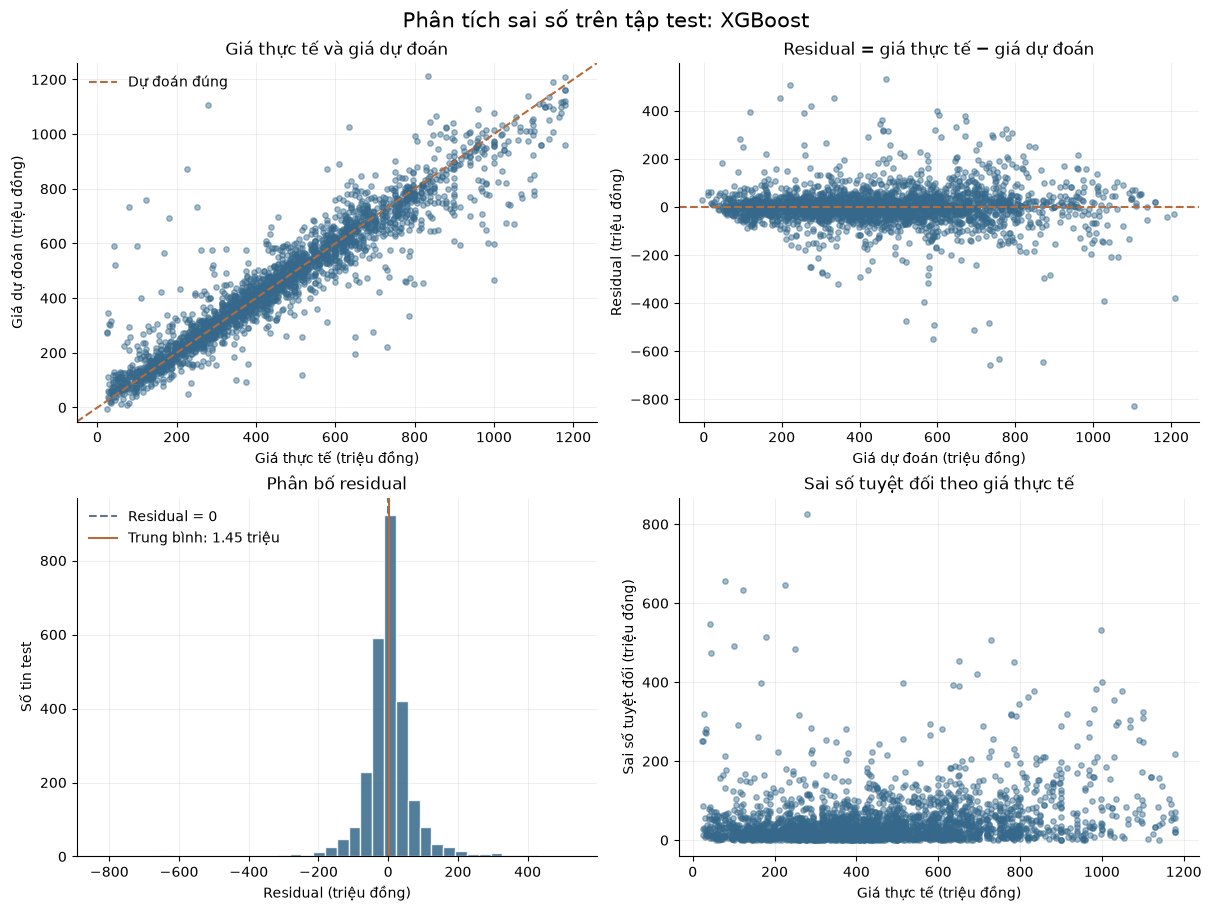

In [11]:
residual_figure = plot_residuals(error_table, best_model_name)
residual_figure.savefig(ERROR_ANALYSIS_DIR / "residual_plots.png", dpi=160)
plt.show()
plt.close(residual_figure)


### Feature importance trên các đặc trưng gốc

Dùng **permutation importance** trên test: xáo trộn từng cột đầu vào 5 lần, giữ Pipeline đã fit, rồi đo mức giảm R² và mức tăng MAE. Xáo trộn trước bước mã hóa nên các cột one-hot của một đặc trưng được xét cùng nhau. Bảng lưu đủ 21 đặc trưng; hình hiển thị 12 đặc trưng có mức giảm R² lớn nhất, với thanh sai số bằng một độ lệch chuẩn giữa các lần xáo trộn.

Giá trị dương lớn cho thấy mô hình phụ thuộc nhiều vào đặc trưng đó trên test. Giá trị gần 0 hoặc âm thể hiện ít cải thiện hoặc dao động trong phép đo, không tự chứng minh đặc trưng vô ích. Các trường liên quan như hãng và dòng xe có thể chia sẻ thông tin, làm importance riêng lẻ giảm; đây là mức phụ thuộc của mô hình, không phải quan hệ nhân quả. Tham khảo: [scikit-learn: permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html).


,Feature,R2_drop,R2_drop_std,MAE_increase,MAE_increase_std
0,car_age,0.8389,0.0290,124.7209,2.8130
1,carmodel_name,0.3385,0.0042,69.6290,0.6451
2,carbrand_name,0.2197,0.0082,36.9452,0.4916
3,fuel,0.1130,0.0030,23.2937,0.6614
4,gearbox,0.1047,0.0031,25.7304,0.4563
5,mileage_v2,0.0296,0.0032,9.7641,0.5660
6,cartype,0.0218,0.0012,8.0168,0.1570
7,carseats,0.0216,0.0013,6.0280,0.1921
8,region_name,0.0065,0.0014,1.6608,0.2586
9,carorigin,0.0064,0.0009,1.6073,0.2118


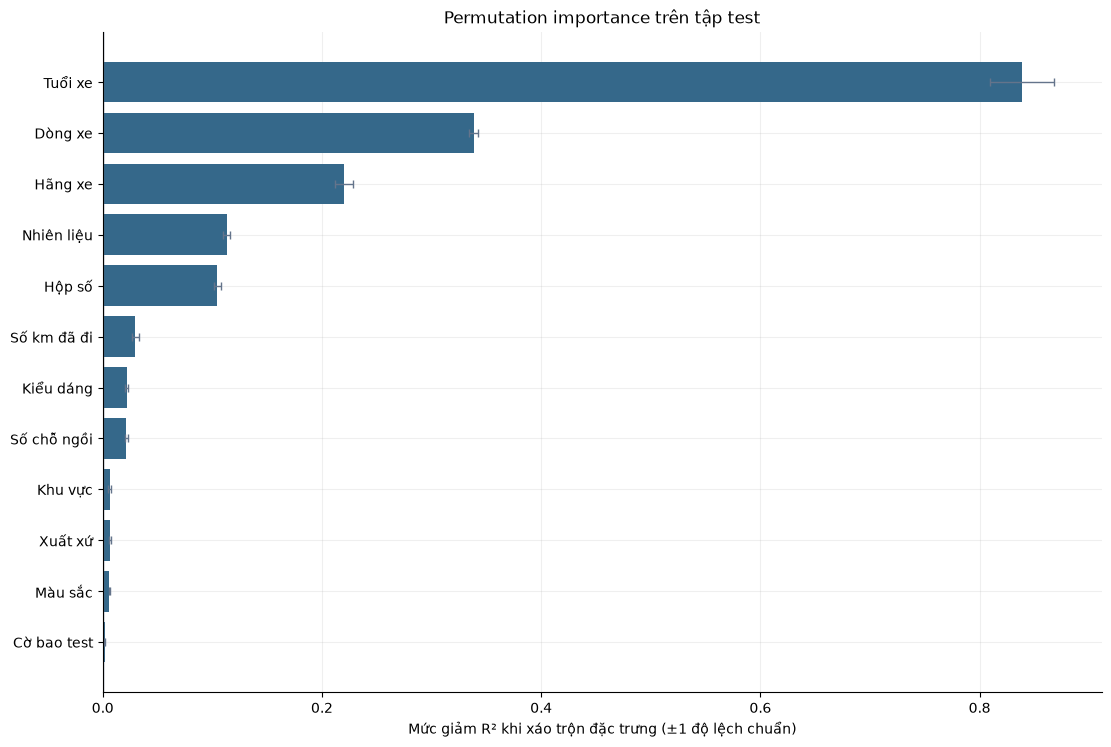

In [12]:
feature_importance = compute_feature_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=IMPORTANCE_REPEATS,
    random_state=RANDOM_STATE,
)
display(feature_importance.round(4))

importance_figure = plot_feature_importance(feature_importance, top_n=12)
importance_figure.savefig(ERROR_ANALYSIS_DIR / "feature_importance.png", dpi=160)
plt.show()
plt.close(importance_figure)


### Sai số theo phân khúc

Phân tích riêng từng chiều: hãng, dòng xe, loại xe, hộp số, nhiên liệu, vùng, có/không có mô tả; thêm các khoảng giá **<300, 300–<600, 600–<900, >=900 triệu**, tuổi xe **<5, 5–<10, 10–<15, >=15 năm** và ODO **<50.000, 50.000–<100.000, 100.000–<200.000, >=200.000 km**. Nhóm dòng xe hiếm được xác định từ tần suất trong train theo đúng ngưỡng mã hóa ở phần 2; dòng xe chưa xuất hiện trong train được ghi riêng.

Mỗi nhóm có số tin train/test, MAE, RMSE, residual trung bình (bias), trung vị sai số tuyệt đối, MAPE, trung vị sai số phần trăm, giá trung vị và tỷ lệ sai lệch không quá 20%. eligible chỉ đánh dấu nhóm có **ít nhất 30 tin test** để xếp hạng; toàn bộ nhóm vẫn được lưu trong CSV.

So sánh cả sai số tiền và sai số tương đối để phân biệt xe đắt sai nhiều tiền với xe rẻ sai nhiều theo phần trăm. Các phân khúc ở những chiều khác nhau có thể chứa cùng một tin, nên không cộng số lượng hoặc sai số giữa các chiều. Nhóm giá dùng giá thực tế cho việc mô tả sau dự đoán, không phải đặc trưng đầu vào.


Các phân khúc sai nhiều nhất theo MAE:


,feature,segment,n_test,n_train,MAE,RMSE,bias,median_absolute_error,MAPE,median_percentage_error,median_actual_price,within_20pct,eligible,MAE_vs_overall
515,price_band,>=900 triệu,135,640,103.25,148.73,90.66,64.01,10.16,5.91,999.0,82.22,True,2.20
523,model_frequency_group,Dòng xe hiếm (<10 tin train),157,573,101.48,148.64,20.65,63.98,35.89,20.31,380.0,47.77,True,2.16
60,carmodel_name,Ranger,119,454,98.78,132.45,-3.24,78.94,34.81,13.35,610.0,72.27,True,2.10
83,carmodel_name,C Class,32,154,83.64,110.27,13.09,67.59,16.60,11.36,725.0,78.12,True,1.78
129,carmodel_name,Dòng khác,75,240,83.60,117.45,12.74,55.80,33.61,17.30,289.0,52.00,True,1.78
431,cartype,Bán tải,165,629,83.49,116.82,-3.21,61.91,29.83,11.82,560.0,74.55,True,1.78
4,carbrand_name,Mercedes Benz,85,444,82.18,111.92,-10.47,59.62,20.77,13.87,599.0,67.06,True,1.75
22,carbrand_name,BMW,38,133,76.95,109.65,8.32,51.25,19.78,12.76,457.5,63.16,True,1.64
435,cartype,Minibus / Xe chuyên dụng,31,107,73.14,105.42,43.06,44.47,20.45,13.45,375.0,70.97,True,1.56
0,carbrand_name,Ford,337,1322,71.67,111.61,3.45,44.51,24.11,10.19,580.0,78.34,True,1.53


Các phân khúc sai nhiều nhất theo MAPE:


,feature,segment,n_test,n_train,MAE,RMSE,bias,median_absolute_error,MAPE,median_percentage_error,median_actual_price,within_20pct,eligible,MAE_vs_overall
113,carmodel_name,Fadil,33,116,31.04,73.50,-23.33,6.85,73.18,2.40,270.0,90.91,True,0.66
512,price_band,<300 triệu,787,3164,42.04,86.38,-21.91,22.56,38.26,12.33,195.0,64.93,True,0.90
523,model_frequency_group,Dòng xe hiếm (<10 tin train),157,573,101.48,148.64,20.65,63.98,35.89,20.31,380.0,47.77,True,2.16
60,carmodel_name,Ranger,119,454,98.78,132.45,-3.24,78.94,34.81,13.35,610.0,72.27,True,2.10
129,carmodel_name,Dòng khác,75,240,83.60,117.45,12.74,55.80,33.61,17.30,289.0,52.00,True,1.78
511,car_age_group,>=15 năm,424,1608,46.92,83.16,3.45,28.08,31.17,18.33,155.0,52.83,True,1.00
431,cartype,Bán tải,165,629,83.49,116.82,-3.21,61.91,29.83,11.82,560.0,74.55,True,1.78
8,carbrand_name,Nissan,34,135,62.30,75.56,-4.97,52.79,29.32,16.61,467.5,64.71,True,1.33
444,fuel,Hybrid,39,136,56.42,120.58,-8.39,29.31,27.95,3.72,650.0,89.74,True,1.20
438,gearbox,Số sàn,570,2222,37.43,67.01,-1.33,21.27,27.20,10.78,215.0,70.18,True,0.80


Phân khúc có MAE cao nhất ở từng chiều:


,feature,segment,n_test,n_train,MAE,RMSE,bias,median_absolute_error,MAPE,median_percentage_error,median_actual_price,within_20pct,eligible,MAE_vs_overall
515,price_band,>=900 triệu,135,640,103.25,148.73,90.66,64.01,10.16,5.91,999.0,82.22,True,2.20
523,model_frequency_group,Dòng xe hiếm (<10 tin train),157,573,101.48,148.64,20.65,63.98,35.89,20.31,380.0,47.77,True,2.16
60,carmodel_name,Ranger,119,454,98.78,132.45,-3.24,78.94,34.81,13.35,610.0,72.27,True,2.10
431,cartype,Bán tải,165,629,83.49,116.82,-3.21,61.91,29.83,11.82,560.0,74.55,True,1.78
4,carbrand_name,Mercedes Benz,85,444,82.18,111.92,-10.47,59.62,20.77,13.87,599.0,67.06,True,1.75
441,fuel,Dầu,471,1810,65.76,100.49,-1.94,42.98,18.21,8.45,600.0,82.38,True,1.40
461,region_name,An Giang,34,122,54.32,95.50,18.90,27.02,16.09,7.20,355.0,79.41,True,1.16
508,car_age_group,<5 năm,957,3972,51.28,88.45,1.16,28.64,13.48,5.43,560.0,91.22,True,1.09
516,mileage_group,<50.000 km,1047,4226,50.81,87.69,5.63,28.64,15.93,6.29,505.0,83.29,True,1.08
439,gearbox,Số tự động,2120,8527,49.50,83.66,1.95,28.64,14.62,6.34,479.0,86.60,True,1.05


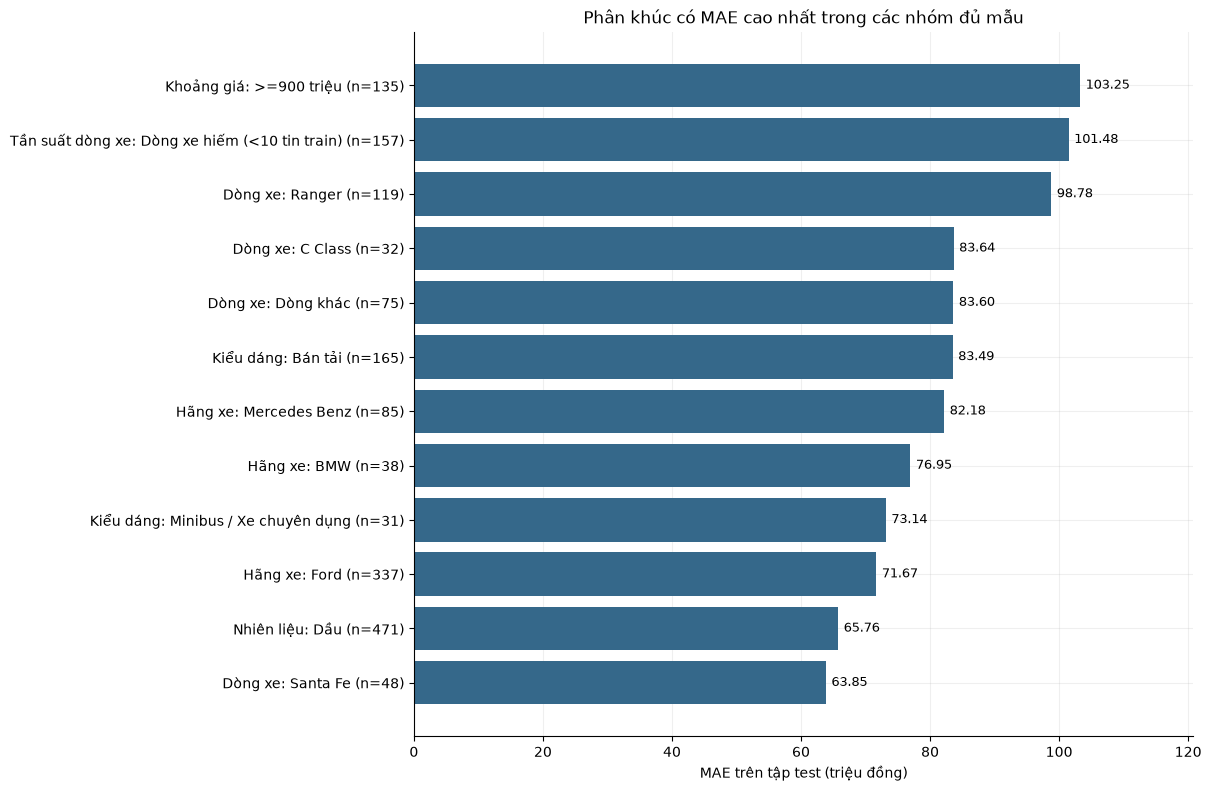

In [13]:
segment_report = build_segment_report(
    error_table,
    X_train,
    y_train,
    min_test_size=MIN_SEGMENT_TEST_SIZE,
    min_model_frequency=MIN_MODEL_FREQUENCY,
)
segment_report["MAE_vs_overall"] = (
    segment_report["MAE"] / error_table["absolute_error"].mean()
    if error_table["absolute_error"].mean() > 0
    else np.nan
)
eligible_segments = segment_report.loc[segment_report["eligible"]].copy()
worst_segments = eligible_segments.sort_values("MAE", ascending=False).head(10)
worst_relative_segments = eligible_segments.sort_values("MAPE", ascending=False).head(10)
worst_by_dimension = eligible_segments.sort_values("MAE", ascending=False).groupby(
    "feature", sort=False
).head(1)

print("Các phân khúc sai nhiều nhất theo MAE:")
display(worst_segments.round(2))
print("Các phân khúc sai nhiều nhất theo MAPE:")
display(worst_relative_segments.round(2))
print("Phân khúc có MAE cao nhất ở từng chiều:")
display(worst_by_dimension.round(2))

segment_figure = plot_segment_errors(segment_report, top_n=12)
segment_figure.savefig(ERROR_ANALYSIS_DIR / "segment_errors.png", dpi=160)
plt.show()
plt.close(segment_figure)


### Phân khúc nào sai nhiều nhất và các khả năng cần kiểm tra

Nhận xét dưới lấy trực tiếp từ các nhóm đủ mẫu và kết quả importance. Đối chiếu mức giá, số tin huấn luyện và độ phủ dòng xe để giải thích những khác biệt quan sát được. Phiên bản, cấp trang bị và tình trạng thực tế chưa có trong tập đặc trưng; tác động của chúng là giả thuyết cần kiểm tra từ tin gốc.

Hai bảng 20 tin có sai số tuyệt đối và sai số phần trăm lớn nhất giữ tiêu đề, mã tin và thông số để hỗ trợ kiểm tra. Tiêu đề chỉ là thông tin đối chiếu ở bước phân tích, không được đưa thêm vào mô hình.


In [14]:
error_findings = describe_errors(error_summary, segment_report, feature_importance, error_table)
display(Markdown(error_findings))

largest_errors = error_table.sort_values("absolute_error", ascending=False).head(20)
listing_columns = [
    "list_id", "subject", "carbrand_name", "carmodel_name", "car_age", "mileage_v2",
    "cartype", "region_name", "y_true", "y_pred", "residual", "absolute_error",
    "percentage_error",
]
with pd.option_context("display.max_colwidth", 80):
    display(largest_errors.loc[:, listing_columns].round(2))

largest_percentage_errors = error_table.sort_values("percentage_error", ascending=False).head(20)
print("Các tin có sai số phần trăm lớn nhất:")
with pd.option_context("display.max_colwidth", 80):
    display(largest_percentage_errors.loc[:, listing_columns].round(2))


- **Sai số tiền lớn nhất:** price_band = **>=900 triệu**, MAE **103.25 triệu VNĐ**, RMSE 148.73; 135 tin test và 640 tin train. Giá trung vị 999.00 triệu, MAPE 10.16%. Residual trung bình 90.66 triệu: dự đoán trung bình thấp hơn giá rao.

- **Sai số tương đối lớn nhất:** carmodel_name = **Fadil**, MAPE **73.18%**, MAE 31.04 triệu trên 33 tin test; trung vị sai số phần trăm 2.40%. MAPE dùng giá từng tin làm mẫu số nên xe giá thấp có thể sai nhiều theo phần trăm.

- **MAPE bị chi phối bởi ít tin:** hai tin sai nhiều theo phần trăm trong nhóm Fadil có giá niêm yết 27.00, 23.46 triệu, đóng góp 92.97% tổng sai số phần trăm của nhóm. Đây là ảnh hưởng của phần đuôi và mẫu số giá thấp; cần đối chiếu giá của hai tin gốc trước khi kết luận lỗi chung cho cả dòng xe.

- **Ảnh hưởng của mức giá:** nhóm >=900 triệu có MAE 103.25 triệu, MAPE 10.16%; nhóm <300 triệu có MAE 42.04 triệu, MAPE 38.26%. Cần đọc hai chỉ số cùng nhau: cùng một tỷ lệ lệch giá tạo ra số tiền sai lớn hơn ở xe đắt, còn MAPE nhạy với mức giá thấp.

- **Độ phủ dòng xe:** nhóm dòng xe hiếm có 157 tin test, MAE 101.48 triệu và MAPE 35.89%; nhóm dòng xe phổ biến có MAE 42.70 triệu và MAPE 15.58%. Ít mẫu và việc nhiều dòng xe dùng chung mã nhóm hiếm là khả năng cần kiểm tra; khác biệt về giá và loại xe cũng có thể ảnh hưởng kết quả này.

- **Sai số tập trung ở đuôi:** 5% tin có sai số lớn nhất đóng góp 65.64% tổng sai số bình phương. Tỷ trọng này cho biết mức RMSE chịu ảnh hưởng của phần đuôi; bảng tin sai nhiều nhất dùng để kiểm tra lại.

- **Thông tin mô hình đang dùng:** các đặc trưng đứng đầu theo mức giảm R² dương: car_age, carmodel_name, carbrand_name. Tập đầu vào chưa có phiên bản động cơ, cấp trang bị hoặc tình trạng xe đã được kiểm chứng. Khác biệt của những yếu tố này giữa các xe cùng dòng là một giả thuyết cho các tin sai lớn, cần kiểm tra từ tin gốc.


Các nhận xét trên mô tả dữ liệu test và đưa ra khả năng cần kiểm tra, chưa xác nhận quan hệ nhân quả. Giá mục tiêu là giá niêm yết; chênh lệch không tự chứng minh mô hình sai về giá giao dịch hoặc người bán rao sai.

,list_id,subject,carbrand_name,carmodel_name,car_age,mileage_v2,cartype,region_name,y_true,y_pred,residual,absolute_error,percentage_error
971,132681731,Hyundai Santa Fe 2024 4x4 Đỏ 18.000 km,Hyundai,Santa Fe,2,18000,NaN,Thái Nguyên,280.00,1105.83,-825.83,825.83,294.94
6243,134075172,Ford Laser 2005 Số sàn Xám,Ford,Laser,1,2588,NaN,Tiền Giang,79.00,735.10,-656.10,656.10,830.50
4513,133898145,Porsche Panamera 4S 2010 Trắng,Porsche,Panamera,16,98900,NaN,Hồ Chí Minh,225.00,870.64,-645.64,645.64,286.95
12434,134613420,Xe Volkswagen Viloran sx 2024 8 chỗ Chính Chủ Bán,Volkswagen,Viloran,2,60000,SUV / Crossover,Đồng Nai,123.46,757.51,-634.06,634.06,513.58
2055,133620742,Ford Ranger XLS 2019 STD Zin Cọp Sơ Cua Chưa Hạ,Ford,Ranger,8,125000,Bán tải,Đắk Nông,41.50,589.70,-548.20,548.20,1320.97
884,132587729,Range Rover Sport Autobiography Dầu 3.0 ***VN,LandRover,Range Rover,14,140000,NaN,Hồ Chí Minh,999.00,467.73,531.27,531.27,53.18
1579,133490213,CUSTIN góp nối. bao nợ xấu. xe trả góp,Hyundai,Custin,1,70000,NaN,Cần Thơ,180.00,693.63,-513.63,513.63,285.35
1513,133396040,"Toyota Camry 2019 2.5Q 7 Vạn Chuẩn, sơn zin 99%",Hyundai,Getz,16,65000,NaN,Hồ Chí Minh,730.00,222.24,507.76,507.76,69.56
10686,134482616,Ford Tourneo 2019 Đen 7 chỗ Tự động 190.000km,Ford,Tourneo,7,190000,NaN,Hà Nội,100.00,591.89,-491.89,491.89,491.89
10377,134445724,Ford Territory Titanium X 2024 góp nói,Ford,Territory,2,20816,SUV / Crossover,Đồng Tháp,250.00,733.45,-483.45,483.45,193.38


Các tin có sai số phần trăm lớn nhất:


,list_id,subject,carbrand_name,carmodel_name,car_age,mileage_v2,cartype,region_name,y_true,y_pred,residual,absolute_error,percentage_error
2055,133620742,Ford Ranger XLS 2019 STD Zin Cọp Sơ Cua Chưa Hạ,Ford,Ranger,8,125000,Bán tải,Đắk Nông,41.50,589.70,-548.20,548.20,1320.97
10431,134450718,VinFast Fadil 2020 Xanh 6 vạn,VinFast,Fadil,6,60000,NaN,Hà Nội,27.00,345.30,-318.30,318.30,1178.90
2798,133705156,VinFast Fadil Đỏ Tự động 5 chỗ,VinFast,Fadil,4,67890,NaN,Nghệ An,23.46,273.56,-250.10,250.10,1066.23
2039,133618249,Hyundai Creta Trắng,Hyundai,Creta,3,20000,SUV / Crossover,Hồ Chí Minh,45.00,519.57,-474.57,474.57,1054.60
8388,134261790,Ford Ranger XLS 2015 Số sàn 1 cầu chính chủ,Ford,Ranger,11,165555,Bán tải,Đắk Lắk,25.00,276.43,-251.43,251.43,1005.72
8861,134306949,cần bán xe Honda Brio 2019 chính chủ biển số thành,Honda,Brio,7,111,Hatchback,Hồ Chí Minh,29.00,303.67,-274.67,274.67,947.14
11237,134522940,Toyota Innova 2017Số sàn 8 chỗ Nâu,Toyota,Innova,10,165000,NaN,Hồ Chí Minh,31.50,303.18,-271.68,271.68,862.46
8970,134318321,Kia Cerato 2016 bản full Trắng,Kia,Cerato,10,80000,Sedan,Quảng Ngãi,33.33,315.91,-282.57,282.57,847.72
6243,134075172,Ford Laser 2005 Số sàn Xám,Ford,Laser,1,2588,NaN,Tiền Giang,79.00,735.10,-656.10,656.10,830.50
12434,134613420,Xe Volkswagen Viloran sx 2024 8 chỗ Chính Chủ Bán,Volkswagen,Viloran,2,60000,SUV / Crossover,Đồng Nai,123.46,757.51,-634.06,634.06,513.58


### Lưu kết quả phân tích

Lưu bảng sai số từng tin, thống kê residual, importance, toàn bộ phân khúc, các nhóm sai nhiều và các tin sai lớn vào models/error_analysis/. Thư mục này cũng chứa ba hình PNG, nhận xét findings.md và cấu hình phân tích để đối chiếu lần chạy.


In [15]:
error_reports = {
    "test_errors.csv": error_table,
    "residual_summary.csv": error_summary.reset_index(names="Metric"),
    "feature_importance.csv": feature_importance,
    "segment_errors.csv": segment_report,
    "worst_segments.csv": worst_segments,
    "worst_relative_segments.csv": worst_relative_segments,
    "worst_by_dimension.csv": worst_by_dimension,
    "largest_errors.csv": largest_errors.loc[:, listing_columns],
    "largest_percentage_errors.csv": largest_percentage_errors.loc[:, listing_columns],
}
for filename, table in error_reports.items():
    table.to_csv(ERROR_ANALYSIS_DIR / filename, index=False, encoding="utf-8-sig")

analysis_config = {
    "model": best_model_name,
    "model_params": best_params,
    "test_rows": len(error_table),
    "random_state": RANDOM_STATE,
    "residual_definition": "y_true - y_pred",
    "permutation_repeats": IMPORTANCE_REPEATS,
    "importance_metrics": ["R2_drop", "MAE_increase"],
    "min_segment_test_size": MIN_SEGMENT_TEST_SIZE,
    "min_model_frequency": MIN_MODEL_FREQUENCY,
    "feature_columns": list(X_test.columns),
    "versions": {
        name: version(name) for name in ("numpy", "pandas", "scikit-learn", "xgboost", "matplotlib")
    },
    "input_sha256": run_config["input_sha256"],
}
(ERROR_ANALYSIS_DIR / "analysis_config.json").write_text(
    json.dumps(analysis_config, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
)
(ERROR_ANALYSIS_DIR / "findings.md").write_text(error_findings, encoding="utf-8")

print(f"Đã lưu {len(error_reports)} bảng, 3 hình và nhận xét vào {ERROR_ANALYSIS_DIR.relative_to(ROOT)}.")


Đã lưu 9 bảng, 3 hình và nhận xét vào models\error_analysis.


## 7. Lưu mô hình

Lưu **toàn bộ Pipeline đã fit trên train** của mô hình được chọn ở phần 5 vào **models/car_pricing_model.pkl**. File chứa ColumnTransformer với các bước điền giá trị thiếu, chuẩn hóa, gom nhóm dòng xe hiếm, one-hot encoding và mô hình hồi quy. Notebook 06 đưa DataFrame gồm các đặc trưng chưa mã hóa vào phương thức predict của Pipeline.

Dùng joblib với mức nén 3. Hàm save_pipeline trong car_pricing/persistence.py kiểm tra trạng thái đã fit, ghi file tạm, kiểm tra dung lượng, nạp lại và đối chiếu dự đoán trên toàn bộ test trước khi chuyển thành file chính thức. Pipeline giữ các tham số đã học từ train.

Ngưỡng kiểm tra là **100.000.000 byte (100 MB)** và file phải **nhỏ hơn** ngưỡng này. Ngưỡng này nhỏ hơn giới hạn 100 MiB mà GitHub chặn khi vượt quá. Tham khảo: [joblib.dump](https://joblib.readthedocs.io/en/stable/generated/joblib.dump.html), [GitHub: giới hạn file](https://docs.github.com/en/repositories/working-with-files/managing-large-files/about-large-files-on-github).


In [10]:
import json
from importlib.metadata import version

import joblib

from car_pricing.persistence import save_pipeline

MAX_MODEL_BYTES = 100_000_000

saved_pipeline, model_save_info = save_pipeline(
    best_model,
    MODEL_PATH,
    validation_features=X_test,
    max_bytes=MAX_MODEL_BYTES,
)

print(
    f"Đã lưu Pipeline {best_model_name} vào {MODEL_PATH.relative_to(ROOT)}; "
    f"dung lượng {model_save_info['file_size_mb']:.2f} MB."
)
display(pd.Series(model_save_info, name="Giá trị").to_frame())


Đã lưu Pipeline XGBoost vào models\car_pricing_model.pkl; dung lượng 0.93 MB.


,Giá trị
file_size_bytes,927867
file_size_mb,0.927867
sha256,f71123cdb3b3d6c95a9eb227431e3bc0ddd8601cd14008...
verified_rows,2704
n_features,21
max_prediction_difference,0.0


### Schema và thông tin mô hình

Lưu thêm **models/car_pricing_model.metadata.json**: danh sách và nhóm đặc trưng, kiểu dữ liệu khi huấn luyện, đơn vị đầu ra triệu VNĐ, tham số đã chọn, chỉ số CV/test, số tin train/test, phiên bản thư viện, dung lượng và SHA-256 của file mô hình.

Đầu vào gồm **21 đặc trưng ở phần 2**. Các nhãn như hãng, dòng xe và hộp số giữ dạng chuỗi; tuổi xe và số km giữ dạng số; cờ văn bản giữ 0/1. Khi dự đoán từ CSV của dự án, ghép dữ liệu sạch với cờ của notebook 04 theo list_id rồi lấy các cột trong feature_columns. Tập đặc trưng đã gồm car_age nên thông tin năm sản xuất được biểu diễn bằng tuổi xe.


In [11]:
MODEL_METADATA_PATH = MODEL_PATH.with_suffix(".metadata.json")

model_metadata = {
    "model_name": best_model_name,
    "artifact_path": MODEL_PATH.relative_to(ROOT).as_posix(),
    "artifact_type": "sklearn.pipeline.Pipeline",
    "pipeline_steps": list(saved_pipeline.named_steps),
    "compression_level": 3,
    "max_file_size_bytes": MAX_MODEL_BYTES,
    "target_column": TARGET_COLUMN,
    "prediction_unit": "million_VND",
    "feature_columns": list(saved_pipeline.feature_names_in_),
    "feature_groups": {name: list(columns) for name, columns in feature_groups.items()},
    "feature_dtypes": X_train.dtypes.astype(str).to_dict(),
    "selected_params": best_params,
    "training_scope": "train",
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "min_model_frequency": MIN_MODEL_FREQUENCY,
    "R2_cv": best_cv_score,
    "test_metrics": best_test_metrics,
    "python_version": sys.version.split()[0],
    "library_versions": {
        name: version(name) for name in ("numpy", "pandas", "scikit-learn", "xgboost", "joblib")
    },
    "input_sha256": run_config["input_sha256"],
    **model_save_info,
}
MODEL_METADATA_PATH.write_text(
    json.dumps(model_metadata, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)

print(f"Đã lưu schema và thông tin mô hình vào {MODEL_METADATA_PATH.relative_to(ROOT)}.")


Đã lưu schema và thông tin mô hình vào models\car_pricing_model.metadata.json.


### Nạp lại và dự đoán từ đặc trưng chưa mã hóa

Cell dưới dùng joblib.load từ đường dẫn chính thức, so sánh dự đoán trước/sau lưu trên toàn bộ test và minh họa năm tin. Mỗi lần predict nhận DataFrame có 21 cột trong metadata, gồm các giá trị số, nhãn danh mục và cờ 0/1; Pipeline tự áp dụng các bước tiền xử lý đã học.

Notebook 06 dùng cùng cách nạp file và gọi predict trên các đặc trưng chuẩn bị theo schema này. Phiên bản môi trường dùng để lưu được ghi trong metadata để đối chiếu khi nạp mô hình.


In [12]:
loaded_pipeline = joblib.load(MODEL_PATH)
loaded_predictions = loaded_pipeline.predict(X_test)
original_predictions = best_model.predict(X_test)
np.testing.assert_allclose(
    loaded_predictions,
    original_predictions,
    rtol=1e-10,
    atol=1e-10,
)

loaded_test_metrics = evaluate_regression(y_test, loaded_predictions, r2_target=R2_TARGET)
np.testing.assert_allclose(
    [loaded_test_metrics[key] for key in ("R2", "MAE", "RMSE")],
    [best_test_metrics[key] for key in ("R2", "MAE", "RMSE")],
    rtol=1e-10,
    atol=1e-10,
)

raw_sample = X_test.head(5).copy()
inference_example = raw_sample.loc[
    :, ["carbrand_name", "carmodel_name", "car_age", "mileage_v2", "gearbox", "fuel", "region_name"]
].copy()
inference_example["Giá dự đoán (triệu VNĐ)"] = loaded_pipeline.predict(raw_sample)

print(f"Nạp lại thành công; dự đoán khớp trên {len(X_test):,} tin test.")
display(pd.Series(loaded_test_metrics, name="Sau nạp lại").to_frame().round(4))
display(inference_example.round(2))


Nạp lại thành công; dự đoán khớp trên 2,704 tin test.


,Sau nạp lại
R2,0.889258
MAE,46.972754
RMSE,80.422642
Meets_R2_target,True


,carbrand_name,carmodel_name,car_age,mileage_v2,gearbox,fuel,region_name,Giá dự đoán (triệu VNĐ)
10146,Ford,Transit,7,145000,Số sàn,Dầu,Hồ Chí Minh,364.579987
8011,Hyundai,Santa Fe,8,80000,Số tự động,Xăng,Hà Nội,579.890015
11176,Toyota,Innova,3,128867,Số sàn,Xăng,Hồ Chí Minh,507.880005
8447,Mazda,CX 5,2,35000,Số tự động,Xăng,Đà Nẵng,700.469971
360,Ford,Ranger,9,90000,Số tự động,Dầu,Hà Nội,417.309998


In [4]:
from pathlib import Path
import joblib

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "requirements.txt").exists()
)

model = joblib.load(root / "models" / "car_pricing_model.pkl")
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0.0,
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(keep_empty_features=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['car_age', 'mileage_v2']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Không '
                                                                           